### Generate thresholds for each smFISH target based on true signal vs background signal

In [1]:
from ioMicro import *

##### Load the raw images in to view and draw layers of polygons around positive/negative signal cells

In [669]:
from dask import array as da
import napari

fls = glob.glob(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\D*\Conv_zscan__126.zarr')
ims = []
for fl in fls:
    ims.append(read_im(fl)[np.newaxis])
ims = da.concatenate(ims)

V = napari.view_image(ims)

##### Select two shape layers of polygons, one for positive (transfected cells) and another for background signal

In [722]:
# load in the coordinates of the masks you drew
coords_neg = [X[:,-2:]for X in V.layers[-1].data] # most recent layer
coords_pos = [X[:,-2:]for X in V.layers[-2].data]

##### Load in a reference hybe, then define positive and negative points (using 1 color channel)

In [909]:
from shapely import Polygon,Point

# specific to this fov and color channel, assumption is that hybe shouldn't matter so much
fov = 126
CRE = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__{fov:03d}--D{7}_fits_icol{2}.npz')['Xh']

pols_pos = [Polygon(X) for X in coords_pos]
pols_neg = [Polygon(X) for X in coords_neg]

vol_pos = np.sum([p.area for p in pols_pos])
vol_neg = np.sum([p.area for p in pols_neg])

CREXY = CRE[:,1:3]

is_positive_cell = [np.any([pol.contains(Point(x)) for pol in pols_pos]) for x in CREXY]
is_negative_cell = [np.any([pol.contains(Point(x)) for pol in pols_neg]) for x in CREXY]

##### Plot brightness values from spots inside positive or negative cells for this fov & color channel

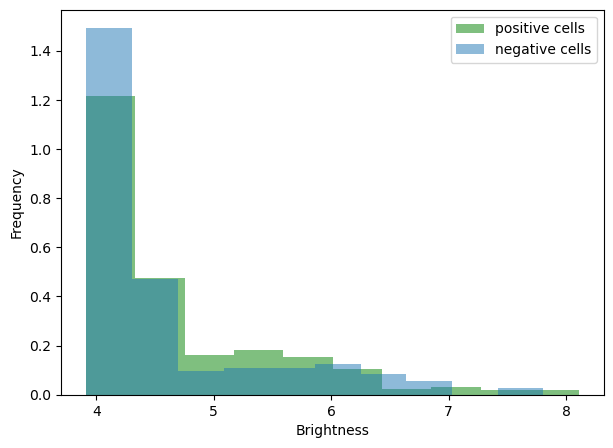

In [910]:
fig, ax = plt.subplots(figsize=(7,5))

ax.hist(np.log(CRE[is_positive_cell][:,-1]),density=True,alpha=0.5, color='g', label = 'positive cells')
ax.hist(np.log(CRE[is_negative_cell][:,-1]),density=True,alpha=0.5, label = 'negative cells')
ax.set_xlabel('Brightness')
ax.set_ylabel('Frequency')
ax.legend()

##### Choose threshold where negative cell signal drops off for this color channel

In [916]:
# Choose a threshold where the "contamination rate" is ~5% or lower
th = np.exp(7.1)
density_pos = np.sum(CRE[is_positive_cell][:,-1]>th)/vol_pos
density_neg = np.sum(CRE[is_negative_cell][:,-1]>th)/vol_neg
print("contamination rate:",density_neg/density_pos)
print(th)
Nneg = np.sum(CRE[is_negative_cell][:,-1]>th) ### mask and color channel dependent, change Nneg number to corresponding color channel

contamination rate: 0.18408162939828265
1211.9670744925763


In [918]:
# chosen for each CRE individually based on above criteria
ths = [812.4,992.2,992.2,
      897.8,812.4,992.2,
      1096.6,1096.6,1212,
      1212,665.1,1096.6,
      1212,1339.4,1096.6,
      1339.4,1808,1339.4,
      1212,1212,1212]

In [921]:
params = [(D,icol) for D in Ds for icol in icols]
final_params = [(D,icol,th)for th,(D,icol) in zip(ths,params)]

In [923]:
final_params

[(1, 0, 812.4),
 (1, 1, 992.2),
 (1, 2, 992.2),
 (2, 0, 897.8),
 (2, 1, 812.4),
 (2, 2, 992.2),
 (3, 0, 1096.6),
 (3, 1, 1096.6),
 (3, 2, 1212),
 (4, 0, 1212),
 (4, 1, 665.1),
 (4, 2, 1096.6),
 (5, 0, 1212),
 (5, 1, 1339.4),
 (5, 2, 1096.6),
 (6, 0, 1339.4),
 (6, 1, 1808),
 (6, 2, 1339.4),
 (7, 0, 1212),
 (7, 1, 1212),
 (7, 2, 1212)]

#### Fine tune thresholds based on manually looking through images: do they look reasonable?

Text(0.5, 1.0, 'raw data')

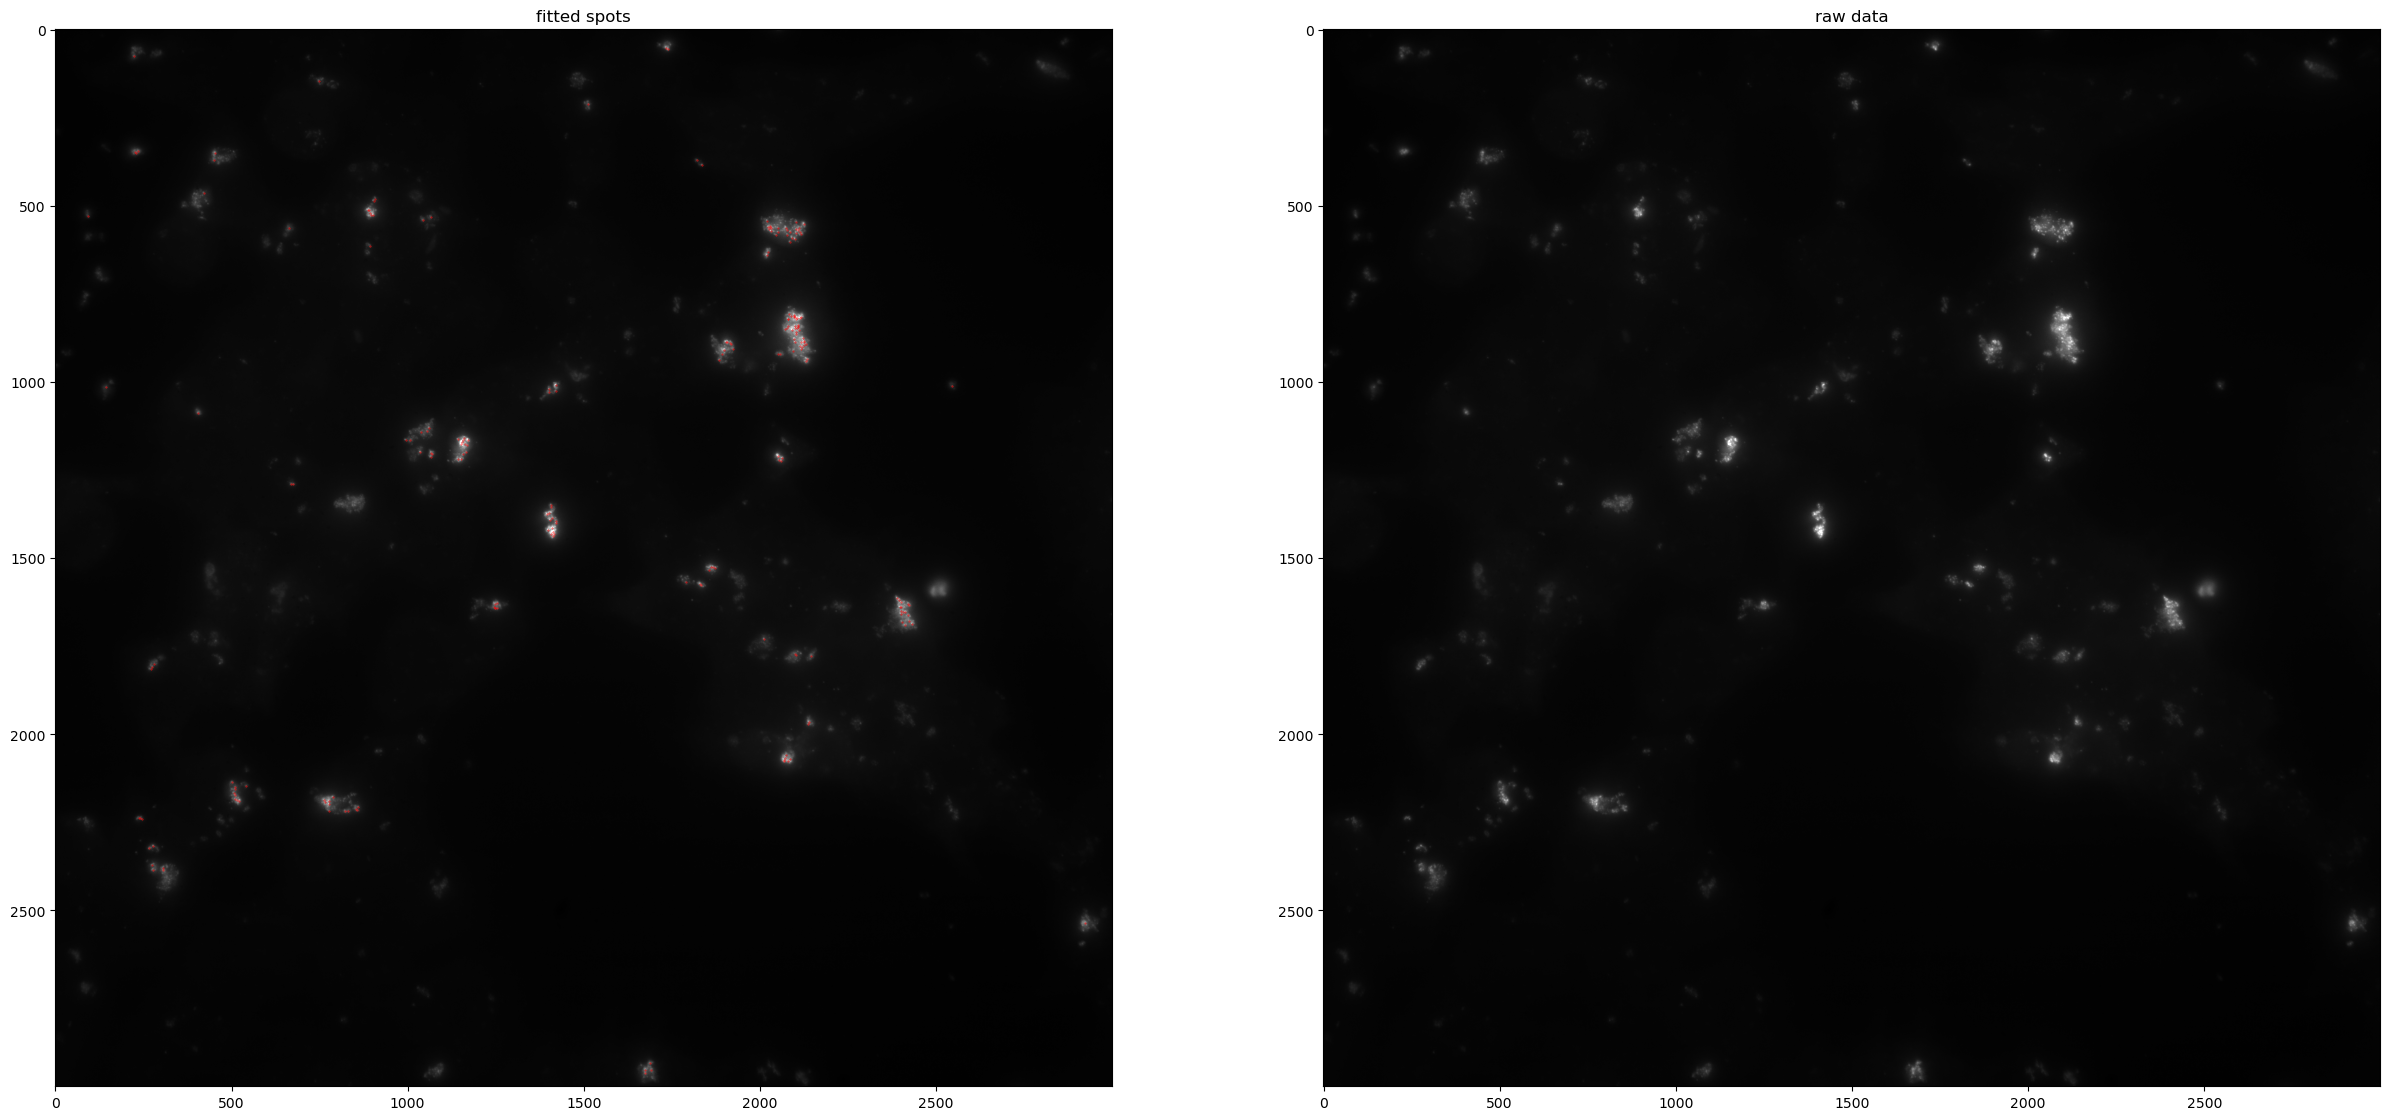

In [917]:
import matplotlib.pyplot as plt

CRE = np.load(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__126--D7_fits_icol2.npz')['Xh']
h = CRE[:,7]
keep = np.where(h>1212)
CRE_ = CRE[keep]

img = read_im(r'Z:\Zane_20CRE\7_17_2024__T7_20CRE\D7\Conv_zscan__126.zarr')

fig, axs = plt.subplots(1, 2, figsize=(30,20))

axs[0].imshow(np.max(img[2,:,:], axis=0), vmax=10000, cmap='gray')
axs[0].scatter(CRE_[:,2], CRE_[:,1], s=0.1, c='r', marker='o')

axs[1].imshow(np.max(img[2,:,:], axis=0), vmax=10000, cmap='gray')
axs[0].set_title('fitted spots')
axs[1].set_title('raw data')
# plt.gca().invert_yaxis()

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_July_2024_analysis\Spot_thresholding\240819_CRE020_fov100.pdf')

##### Get the thresholds across all the hybes and color channels for this fov

In [367]:
ths = []
fov = 30
Ds = [1,2,3,4,5,6,7]
icols = [0,1,2]
for D in tqdm(Ds):
    for icol in icols:
        CREN = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__{fov:03d}--D{D}_fits_icol{icol}.npz')['Xh']
        CREXY = CREN[:,1:3]
        is_positive_cellN = [np.any([pol.contains(Point(x)) for pol in pols_pos]) for x in CREXY]
        is_negative_cellN = [np.any([pol.contains(Point(x)) for pol in pols_neg]) for x in CREXY]
        # th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_0]

        if D == 1: 
            if icol == 0:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_001]
    
            if icol == 1:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_002]
            
            if icol == 2:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_003]

        if D == 2: 
            if icol == 0:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_004]
    
            if icol == 1:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_005]
            
            if icol == 2:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_006]

        if D == 3: 
            if icol == 0:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_007]
    
            if icol == 1:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_008]
            
            if icol == 2:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_009]

        if D == 4: 
            if icol == 0:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_010]
    
            if icol == 1:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_011]
            
            if icol == 2:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_012]

        if D == 5: 
            if icol == 0:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_013]
    
            if icol == 1:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_014]
            
            if icol == 2:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_015]

        if D == 6: 
            if icol == 0:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_016]
    
            if icol == 1:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_017]
            
            if icol == 2:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_018]

        if D == 7: 
            if icol == 0:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_019]
    
            if icol == 1:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_020]
            
            if icol == 2:
                th_current = np.sort(CREN[is_negative_cellN][:,-1])[-Nneg_021]
        
        ths.append(th_current)

100%|███████████████████████████████████████████████████████████████████████████████████| 7/7 [12:23<00:00, 106.19s/it]


In [418]:
params = [(D,icol) for D in Ds for icol in icols]
final_params = [(D,icol,th)for th,(D,icol) in zip(ths,params)]

In [428]:
Ns = []
for (D,icol,th) in final_params:
    CREN = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__100--D{D}_fits_icol{icol}.npz')['Xh']
    Ns.append(np.sum(CREN[:,-1]>th))

In [429]:
np.corrcoef(np.log(countsSeq),np.log(Ns[:-1]))

array([[1.        , 0.60046602],
       [0.60046602, 1.        ]])

##### Load in plasmid sequencing data for this library

In [81]:
countsSeq = [eval(ln[:-1].split(' CRE')[0]) for ln in open(r'C:\Users\zgibbs\cellpose\bulk_sequencing\plasmidsaurus_20250213\N5LC7G_2_sample_2_counts','r')]

In [379]:
np.corrcoef(np.log(countsSeq),np.log(Ns[:-1]))

array([[1.        , 0.63095528],
       [0.63095528, 1.        ]])

In [398]:
OG_ths = np.load('final_parms_ths.npz')['final_parms']

In [406]:
OG_ths = OG_ths.astype(int)

In [456]:
Ns = []
for (D,icol,th) in OG_ths:
    CREN = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__000--D{D}_fits_icol{icol}.npz')['Xh']
    Ns.append(np.sum(CREN[:,-1]>th))

In [441]:
np.corrcoef(np.log(countsSeq),np.log(Ns[:-1]))

array([[1.        , 0.81093792],
       [0.81093792, 1.        ]])

##### Create dataframe containing thresholded counts for each T7 species across the dataset

In [924]:
CRE_id = []

for cre in range(1,21):
    id = f'CRE{cre:03d}'
    CRE_id.append(id)

CRE_id.append('blank')

In [925]:
total_ths_df = pd.DataFrame(index=CRE_id)

for fov in tqdm(range(225)):
    total_ths = []
    for (D,icol,th) in final_params:
        CREN = np.load(rf'Z:\Zane_20CRE\7_17_2024__T7_20CRE\analysis\Conv_zscan__{fov:03d}--D{D}_fits_icol{icol}.npz')['Xh']
        total_ths.append(np.sum(CREN[:,-1]>th))

    total_ths_df[f'{fov:03d}'] = total_ths

# total_ths_df = total_ths_df.astype(int)

 44%|███████████████████████████████████▌                                            | 100/225 [02:02<03:08,  1.51s/it]C:\Users\zgibbs\AppData\Local\Temp\ipykernel_33848\2101444774.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  total_ths_df[f'{fov:03d}'] = total_ths
 45%|███████████████████████████████████▉                                            | 101/225 [02:04<03:09,  1.53s/it]C:\Users\zgibbs\AppData\Local\Temp\ipykernel_33848\2101444774.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  total_ths_df[f'{fov:03d}'] = 

In [926]:
total_ths_df

,000,001,002,003,004,005,006,007,008,009,...,215,216,217,218,219,220,221,222,223,224
CRE001,1417,1961,539,978,2238,2000,1313,1317,2567,1073,...,2337,1599,1968,2860,1749,1739,832,10,1068,1555
CRE002,3509,4023,1340,1736,4548,4279,2795,2896,5221,1973,...,5720,3874,4433,6233,3945,4208,2183,43,2383,3549
CRE003,3932,4351,1411,1613,4579,4260,2676,2730,5944,1921,...,5396,3691,4299,7105,4194,4292,2004,18,2287,3594
CRE004,2416,2970,836,1157,2997,2791,1673,1825,3585,1244,...,2938,2181,2785,4909,2954,2519,1112,21,1569,2380
CRE005,1849,2296,626,989,2394,2232,1417,1437,2438,1282,...,2509,1856,2116,3417,2289,1872,977,13,1316,1758
CRE006,627,1271,277,573,1215,1163,610,641,1291,677,...,682,591,718,1311,844,619,293,0,524,928
CRE007,2689,2956,930,1242,3449,3080,1930,2116,4134,1442,...,3908,2773,3364,5260,3188,3142,1552,21,1880,2572
CRE008,2181,3398,894,1309,3378,3035,1802,1935,3694,1414,...,3556,2479,3315,5523,3315,2837,1288,14,1788,2774
CRE009,680,1366,282,580,1287,1207,610,703,1329,617,...,668,665,853,1386,893,661,306,0,457,960
CRE010,969,1638,453,727,1656,1469,925,1055,1769,886,...,1161,968,1155,1927,1313,1088,474,6,802,1221


##### Plot the correlation between T7 transcripts and plasmid library counts

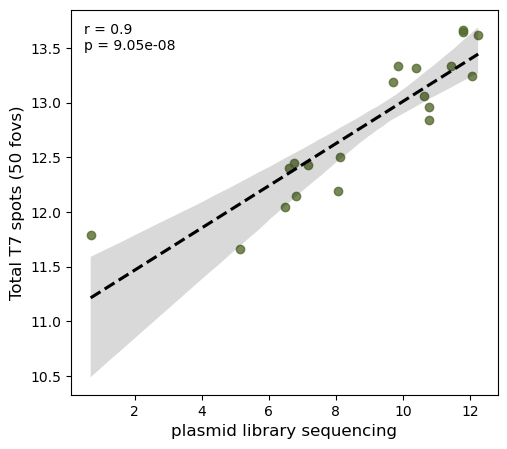

In [927]:
from matplotlib.offsetbox import AnchoredText
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(5.5,5))

x = np.log(countsSeq)
y = np.log(total_ths_df[:-1].sum(axis=1))

# sns.set_palette("viridis")

sns.regplot(x=x, y=y,
            color='darkolivegreen',
            line_kws={'ls' : 'dashed', 'color' : 'k'})

ax.set_xlabel('plasmid library sequencing', fontsize=12)
ax.set_ylabel('Total T7 spots (50 fovs)', fontsize=12)
# ax.set_yscale('log')

stats = stats.pearsonr(x, y)

corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)

# plt.savefig('/projects/ps-renlab2/zgibbs/STARR-FISH/10_12_2023__CRE-20_RNASEQ_rep/figures/bulk_RNA-seq_corr_between_reps.png', dpi=600)
plt.show()

In [935]:
total_ths_df[:-1].sum(axis=1)

CRE001    377658
CRE002    821884
CRE003    841055
CRE004    535367
CRE005    423737
CRE006    188769
CRE007    619638
CRE008    607563
CRE009    197102
CRE010    268306
CRE011    132225
CRE012    250792
CRE013    859834
CRE014    116240
CRE015    169721
CRE016    243836
CRE017    615624
CRE018    468598
CRE019    254361
CRE020    565132
dtype: int64

C:\Users\zgibbs\AppData\Local\Temp\ipykernel_33848\3945208041.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.annotate(txt, (x[i], y[i]), **kwargs)


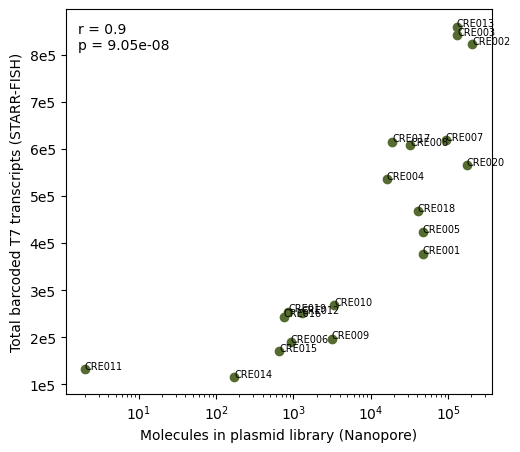

In [934]:
from scipy import stats
import matplotlib.ticker as ticker
from matplotlib.ticker import FuncFormatter

majorFormatter = FuncFormatter(MyFormatter)

x = countsSeq
y = total_ths_df[:-1].sum(axis=1)

fig, ax = plt.subplots(figsize=(5.5,5))

ax.loglog(x, y, 'o', c='darkolivegreen')

ax.set_yscale('linear')
ax.set_xlabel('Molecules in plasmid library (Nanopore)')
ax.set_ylabel('Total barcoded T7 transcripts (STARR-FISH)')
ax.yaxis.set_major_formatter(majorFormatter)

stats = stats.pearsonr(np.log(x), np.log(y))
corrcoef = np.around(stats[0], 2)
pval = np.format_float_scientific(stats[1], 2)

anchored_text = AnchoredText(f"r = {corrcoef}\np = {pval}", loc=2, frameon=False)
ax.add_artist(anchored_text)


# add labels to each point on the scatter plot
kwargs = {'size':'7'}
for i, txt in enumerate(total_ths_df[:-1].index):
    ax.annotate(txt, (x[i], y[i]), **kwargs)

# plt.savefig(r'C:\Users\zgibbs\STARR-FISH\figures\20CRE_T7_analysis\T7spots_vs_nanopore_corr_log_250321.pdf')
plt.show()

##### Allows you to set tick labels to scientific notation

In [661]:
def MyFormatter(x,lim):
    if x == 0:
        return 0
    return '{0:.0f}e{1:.0f}'.format(np.sign(x)*10**(-np.floor(np.log10(abs(x)))+np.log10(abs(x))),np.floor(np.log10(abs(x))))
    #The first argument of the format gives the first significant digits of the number with the sign preserved and brought to a range between [1-10), The next argument gives the  numbers integer exponent of 10
    #Both the first and second arguments are formatted to display only 2 decimal places due to the lack of space.


##### Save the final threshold parameters

In [938]:
np.savez('T7_final_params_ths.npz',final_params=final_params)
#final_parms

In [937]:
final_params

[(1, 0, 812.4),
 (1, 1, 992.2),
 (1, 2, 992.2),
 (2, 0, 897.8),
 (2, 1, 812.4),
 (2, 2, 992.2),
 (3, 0, 1096.6),
 (3, 1, 1096.6),
 (3, 2, 1212),
 (4, 0, 1212),
 (4, 1, 665.1),
 (4, 2, 1096.6),
 (5, 0, 1212),
 (5, 1, 1339.4),
 (5, 2, 1096.6),
 (6, 0, 1339.4),
 (6, 1, 1808),
 (6, 2, 1339.4),
 (7, 0, 1212),
 (7, 1, 1212),
 (7, 2, 1212)]